In [143]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [144]:
radiomics_df= pd.read_csv("C:/Users/sonic/Desktop/Dissertation/resources/development/tcia_radiomic_features.csv", index_col="id")
clinical_df= pd.read_csv("C:/Users/sonic/Desktop/Dissertation/resources/development/tcia_clinical.csv", index_col="id")


In [145]:
radiomics_df.shape
print("radiomics dataset shape:", radiomics_df.shape)
clinical_df.shape
print("clinical dataset shape:", clinical_df.shape)

radiomics dataset shape: (140, 100)
clinical dataset shape: (211, 44)


In [146]:
print(radiomics_df)

         original_shape_Elongation  original_shape_Flatness  \
id                                                            
R01-001                   0.692257                 0.477226   
R01-002                   0.725333                 0.655776   
R01-003                   0.699943                 0.632518   
R01-004                   0.606498                 0.386138   
R01-005                   0.775179                 0.666254   
...                            ...                      ...   
R01-141                   0.626490                 0.471287   
R01-142                   0.697724                 0.637870   
R01-144                   0.955050                 0.481380   
R01-145                   0.906495                 0.802389   
R01-146                   0.667960                 0.556259   

         original_shape_LeastAxisLength  original_shape_MajorAxisLength  \
id                                                                        
R01-001                       

In [147]:
print(clinical_df)

        Patient affiliation  Age at Histological Diagnosis  Weight (lbs)  \
id                                                                         
AMC-001            Stanford                           34.0           NaN   
AMC-002            Stanford                           33.0           NaN   
AMC-003            Stanford                           69.0           NaN   
AMC-004            Stanford                           80.0           NaN   
AMC-005            Stanford                           76.0           NaN   
...                     ...                            ...           ...   
R01-159            Stanford                           75.0         184.0   
R01-160                  VA                           61.0         231.5   
R01-161            Stanford                           52.0           NaN   
R01-162            Stanford                           67.0         158.0   
R01-163                  VA                           68.0         229.0   

        Smo

In [148]:
print(radiomics_df.columns)

Index(['original_shape_Elongation', 'original_shape_Flatness',
       'original_shape_LeastAxisLength', 'original_shape_MajorAxisLength',
       'original_shape_Maximum2DDiameterColumn',
       'original_shape_Maximum2DDiameterRow',
       'original_shape_Maximum2DDiameterSlice',
       'original_shape_Maximum3DDiameter', 'original_shape_MeshVolume',
       'original_shape_MinorAxisLength', 'original_shape_Sphericity',
       'original_shape_SurfaceArea', 'original_shape_SurfaceVolumeRatio',
       'original_shape_VoxelVolume', 'original_firstorder_10Percentile',
       'original_firstorder_90Percentile', 'original_firstorder_Energy',
       'original_firstorder_Entropy', 'original_firstorder_InterquartileRange',
       'original_firstorder_Kurtosis', 'original_firstorder_Maximum',
       'original_firstorder_MeanAbsoluteDeviation', 'original_firstorder_Mean',
       'original_firstorder_Median', 'original_firstorder_Minimum',
       'original_firstorder_Range',
       'original_firsto

In [149]:
print(clinical_df.columns)

Index(['Patient affiliation', 'Age at Histological Diagnosis', 'Weight (lbs)',
       'Smoking status', 'Pack Years', 'Quit Smoking Year', '%GG',
       'Tumor Location (choice=RUL)', 'Tumor Location (choice=RML)',
       'Tumor Location (choice=RLL)', 'Tumor Location (choice=LUL)',
       'Tumor Location (choice=LLL)', 'Tumor Location (choice=L Lingula)',
       'Tumor Location (choice=Unknown)', 'Histology', 'Pathological T stage',
       'Pathological N stage', 'Pathological M stage',
       'Histopathological Grade', 'Lymphovascular invasion',
       'Pleural invasion (elastic, visceral, or parietal)', 'EGFR', 'KRAS',
       'ALK', 'Adjuvant Treatment', 'Chemotherapy', 'Radiation', 'Recurrence',
       'Recurrence Location', 'Date of Recurrence', 'Date of Last Known Alive',
       'Survival Status', 'Date of Death', 'Time to Death (days)', 'CT Date',
       'Days between CT and surgery', 'PET Date', 'Gender_Female',
       'Gender_Male', 'Ethnicity_African-American', 'Ethnicity_Asi

In [150]:
### merging
# Merge and immediately de-fragment the memory
# doubt-
"""merged_df = radiomics_df.join(clinical_df, how="inner") or merged_df = pd.merge(radiomics_df, clinical_df, on="id", how="inner") which is efficient? shd i index it with ID or not?
"""
merged_df = pd.merge(radiomics_df, clinical_df, on="id", how="inner").copy()
print(merged_df)
merged_df.head()

         original_shape_Elongation  original_shape_Flatness  \
id                                                            
R01-001                   0.692257                 0.477226   
R01-002                   0.725333                 0.655776   
R01-003                   0.699943                 0.632518   
R01-004                   0.606498                 0.386138   
R01-005                   0.775179                 0.666254   
...                            ...                      ...   
R01-141                   0.626490                 0.471287   
R01-142                   0.697724                 0.637870   
R01-144                   0.955050                 0.481380   
R01-145                   0.906495                 0.802389   
R01-146                   0.667960                 0.556259   

         original_shape_LeastAxisLength  original_shape_MajorAxisLength  \
id                                                                        
R01-001                       

C:\Users\sonic\AppData\Local\Temp\ipykernel_21320\4266950149.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df = pd.merge(radiomics_df, clinical_df, on="id", how="inner").copy()


,original_shape_Elongation,original_shape_Flatness,original_shape_LeastAxisLength,original_shape_MajorAxisLength,original_shape_Maximum2DDiameterColumn,original_shape_Maximum2DDiameterRow,original_shape_Maximum2DDiameterSlice,original_shape_Maximum3DDiameter,original_shape_MeshVolume,original_shape_MinorAxisLength,...,CT Date,Days between CT and surgery,PET Date,Gender_Female,Gender_Male,Ethnicity_African-American,Ethnicity_Asian,Ethnicity_Caucasian,Ethnicity_Hispanic/Latino,Ethnicity_Native Hawaiian/Pacific Islander
id,,,,,,,,,,,,,,,,,,,,,
R01-001,0.692257,0.477226,8.885322,18.618692,19.849433,20.615528,17.464249,22.825424,1275.458333,12.888928,...,09/06/1990,42,10/17/1990,1.0,0.0,0.0,0.0,1.0,0.0,0.0
R01-002,0.725333,0.655776,12.372723,18.867299,18.601075,25.059928,20.808652,25.139610,2095.750000,13.685078,...,9/20/1990,23,10/11/1990,1.0,0.0,0.0,1.0,0.0,0.0,0.0
R01-003,0.699943,0.632518,10.714132,16.938860,15.264338,20.396078,20.248457,21.908902,1334.458333,11.856234,...,12/10/1991,25,12/19/1991,0.0,1.0,0.0,0.0,1.0,0.0,0.0
R01-004,0.606498,0.386138,8.365505,21.664551,19.849433,24.207437,18.867962,25.019992,1255.916667,13.139498,...,09/09/1991,89,10/17/1991,0.0,1.0,0.0,0.0,1.0,0.0,0.0
R01-005,0.775179,0.666254,18.325835,27.505789,31.400637,27.459060,32.649655,33.778692,7059.750000,21.321913,...,03/08/1991,92,4/19/1991,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [151]:
print(merged_df.info())

<class 'pandas.DataFrame'>
Index: 140 entries, R01-001 to R01-146
Columns: 144 entries, original_shape_Elongation to Ethnicity_Native Hawaiian/Pacific Islander
dtypes: float64(115), int64(1), str(28)
memory usage: 158.6+ KB
None


In [152]:
print(merged_df.isna().sum())

original_shape_Elongation                     0
original_shape_Flatness                       0
original_shape_LeastAxisLength                0
original_shape_MajorAxisLength                0
original_shape_Maximum2DDiameterColumn        0
                                             ..
Ethnicity_African-American                    0
Ethnicity_Asian                               0
Ethnicity_Caucasian                           0
Ethnicity_Hispanic/Latino                     0
Ethnicity_Native Hawaiian/Pacific Islander    0
Length: 144, dtype: int64


In [153]:
print(merged_df.describe())

       original_shape_Elongation  original_shape_Flatness  \
count                 140.000000               140.000000   
mean                    0.777290                 0.605993   
std                     0.135916                 0.136912   
min                     0.339180                 0.240246   
25%                     0.699388                 0.520460   
50%                     0.793728                 0.610430   
75%                     0.889206                 0.702108   
max                     0.983641                 0.876837   

       original_shape_LeastAxisLength  original_shape_MajorAxisLength  \
count                      140.000000                      140.000000   
mean                        21.892288                       37.004485   
std                         12.295691                       19.512351   
min                          6.964471                       11.326879   
25%                         14.142889                       22.930394   
50%         

In [154]:
def get_features(merged_df):
    """Extract radiomic feature columns"""
    features = [col for col in merged_df.columns if col.startswith('original_')]
    return features

In [155]:
# Run your function
radiomics_features = get_features(merged_df)

# Check how many features it found, and look at the first 5 names
print(f"Found {len(radiomics_features)} radiomics features.")
print("First 5 features found:", my_features[:5])

Found 100 radiomics features.
First 5 features found: ['original_shape_Elongation', 'original_shape_Flatness', 'original_shape_LeastAxisLength', 'original_shape_MajorAxisLength', 'original_shape_Maximum2DDiameterColumn']


In [156]:
# Calculate how many missing values are in each column
missing_per_col = merged_df.isna().sum()

# Filter to show only columns that have at least one missing value
missing_cols = missing_per_col[missing_per_col > 0].sort_values(ascending=False)

print(f"Total columns with missing data: {len(missing_cols)}")
print("\nTop 15 columns with the most missing values:")
print(missing_cols.head(15))

Total columns with missing data: 10

Top 15 columns with the most missing values:
Recurrence Location        100
Date of Recurrence         100
Time to Death (days)        89
Date of Death               89
Quit Smoking Year           67
ALK                         31
KRAS                        27
EGFR                        25
Weight (lbs)                 9
Lymphovascular invasion      5
dtype: int64


In [166]:
# Create feature table using your working list from earlier
X = merged_df[my_features]

# Verify that it has absolutely zero missing values
print(f"Total missing values in your feature table: {X.isna().sum().sum()}")

Total missing values in your feature table: 0


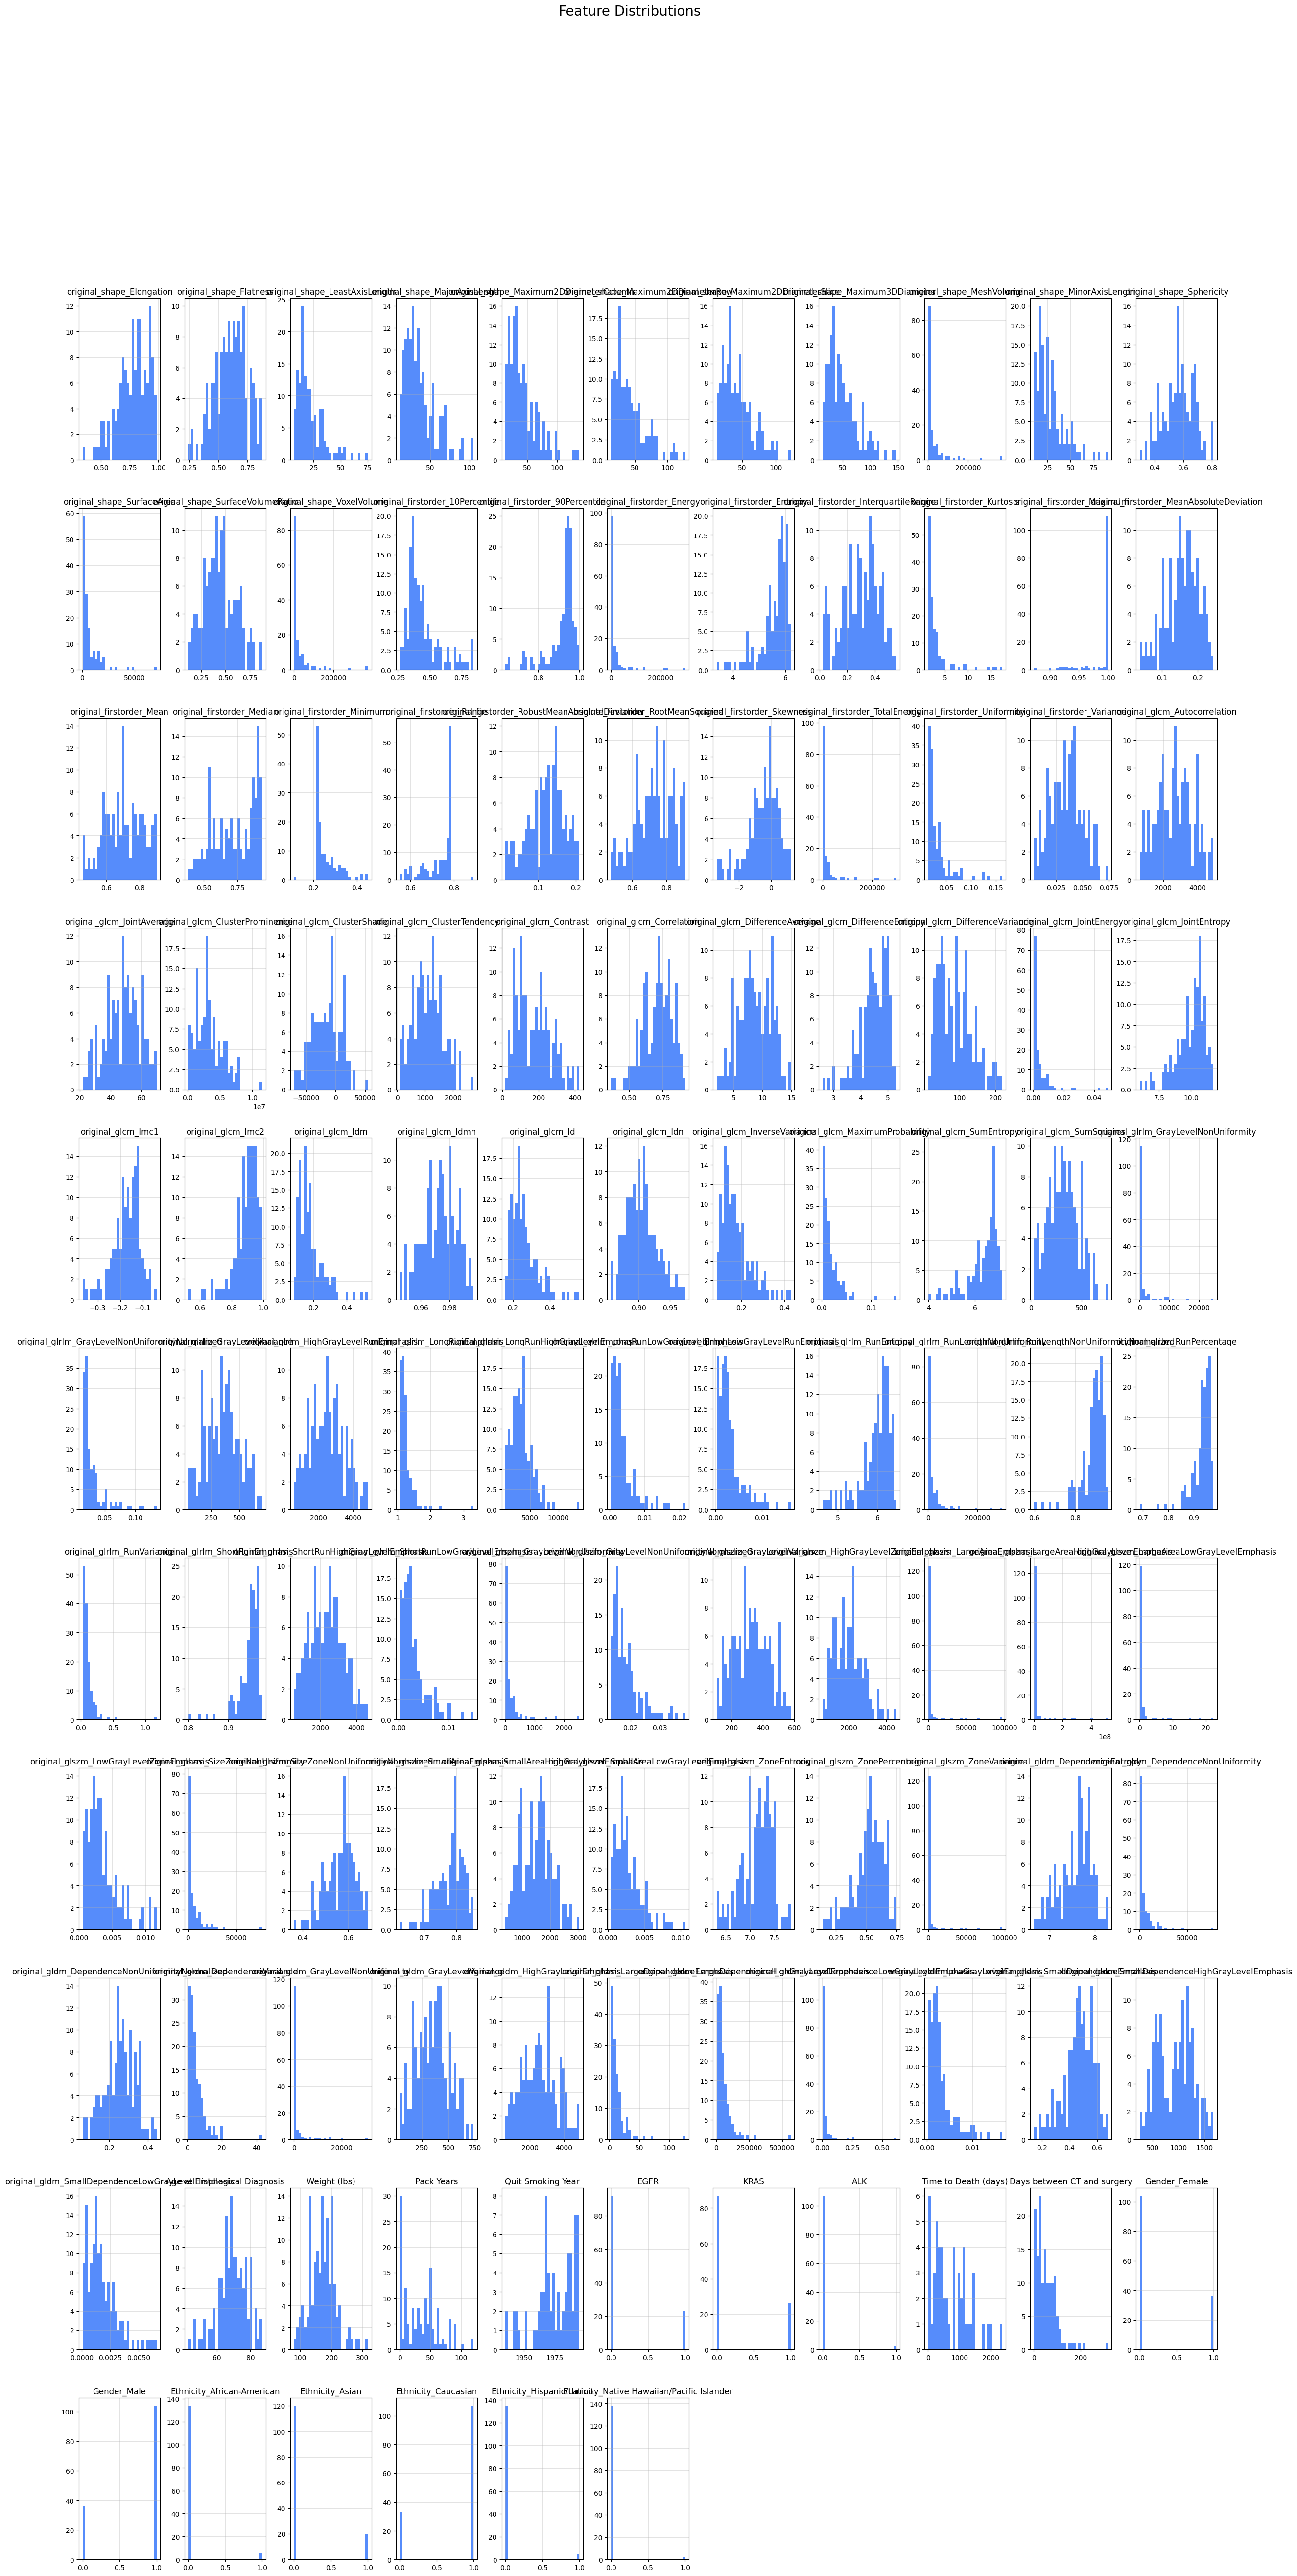

In [163]:
merged_df.hist(figsize=(30, 60), bins=30)
plt.suptitle("Feature Distributions", fontsize=20)
plt.show()

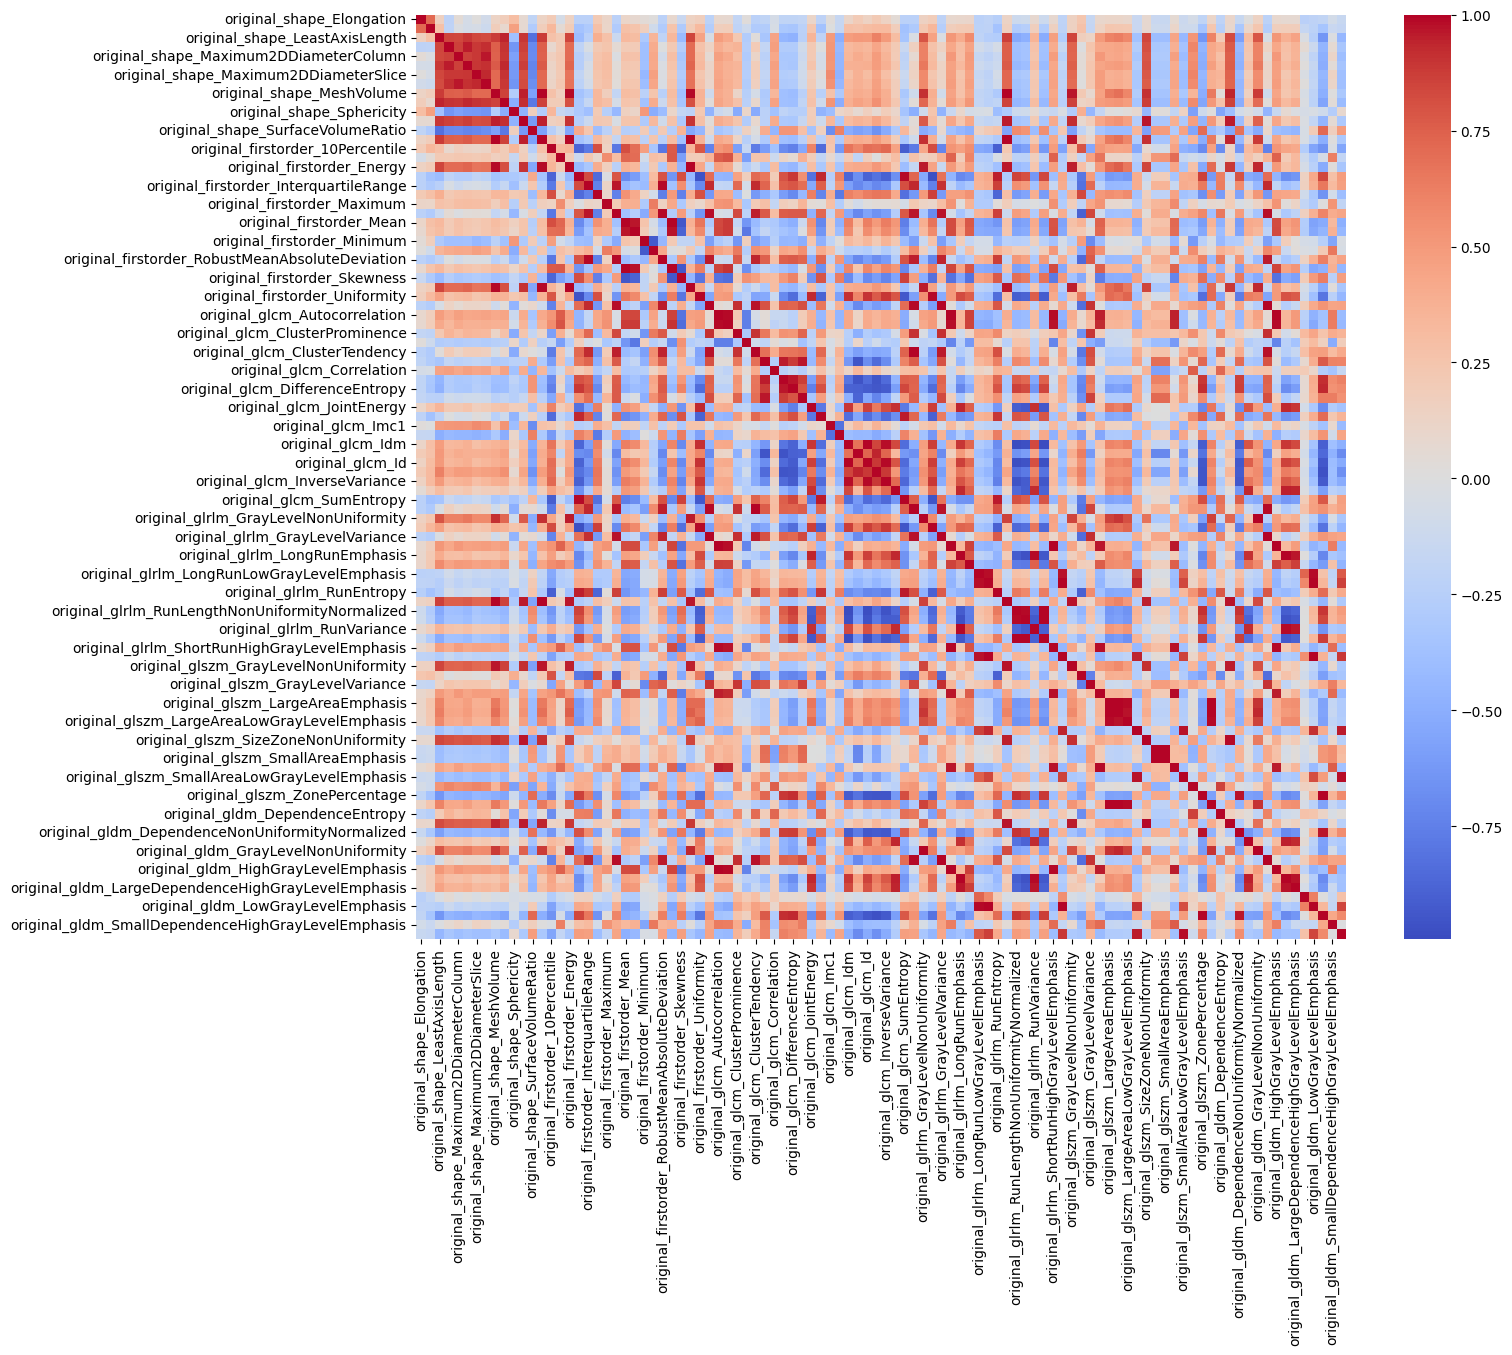

In [161]:
#which variable is strongly correlated?
corr = X.corr()

plt.figure(figsize=(15,12))
sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)
plt.show()

In [174]:
##Check for variance
zero_var = [col for col in my_features if merged_df[col].var() == 0]
print(f"Features with Zero Variance: {len(zero_var)}")
if zero_var:
    print(f"-> Drop these zero-variance columns: {zero_var}")

Features with Zero Variance: 0


In [176]:
corr_matrix = df[features].corr().abs()

high_corr_pairs = 0

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):

        if corr_matrix.iloc[i,j] >= 0.80:
            high_corr_pairs +=1

print(
    f"Highly correlated pairs (r ≥ 0.80): {high_corr_pairs}"
)

Highly correlated pairs (r ≥ 0.80): 0
